# データとtoken数の目視確認

最初のconfiguration cellを変更し、**Restart Kernel and Run All Cells** で上から実行してください。
既存のraw reader・inventory・preprocessing・token counterを呼ぶ閲覧用Notebookです。
data/の取得物、既存CSV、batch結果には書き込みません。OpenAI API・LLM評価・simulationは実行しません。

一覧は公式20 task＋外部5候補。Baiduは未取得、公式9 taskはrawのみで元promptは未対応です。
Notebookの保存出力は実行時の設定に対応するsnapshotなので、設定変更後は全セルを再実行してください。


In [4]:
DATASET = "MountainCar-v0"
EPISODE = 0
QUERY_INDEX = 10
HISTORY_SIZE = 1
HISTORY_SIZES = [0, 1, 2, 3, 5]

# None / None: 選択taskの既存LLM-X既定質問を使用。
# 指定する場合は両方変更。例: "next-action", "next_action_prediction"
METRIC = None
QUESTION_NAME = None
MODEL = "gpt-4o"

# 外部trajectory: SEQUENCE_IDとQUERY_INDEX。static: ROW_ID（全reader単位の通し番号）。
SEQUENCE_ID = None
ROW_ID = None

# 外部token表示は明示的に指定した場合だけ。Noneならraw inspectionのみ。
# 例: "configs/preprocessing/f16capstone_default.yaml"
PREPROCESSING_CONFIG = None
EXTERNAL_FULL_DATASET = False  # Trueで明示設定scope全体。既定は選択sequenceのみ。
MAX_EXTERNAL_QUERIES = 100_000 # 上限を超える計測は実行しない（sampleを全件に見せない）。


In [ ]:
from pathlib import Path
import sys
import json
import pandas as pd
from IPython.display import display, Markdown

# workspace直下／notebooks/のどちらから起動しても同じ既存moduleをimport。
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "dataset_adapters").is_dir() and (p / "configs/sources.json").is_file()), None)
if ROOT is None:
    raise RuntimeError("workspace直下またはnotebooks/から起動してください。")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from dataset_adapters.registry import get_adapter, EXTERNAL
from tools.notebook_inspection import (
    dataset_table, select_record, inspect_selected_file, preview_raw,
    preprocessing_for_inspection, selected_query, token_record,
    dataset_token_table, table_statistics, read_batch_summary,
)
from tools.count_input_tokens import resolve_encoding

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)
print("Workspace:", ROOT)
print("Read-only inspection. No API client or API request.")


Workspace: /Users/cls-lab/Git/Matsuo/mental-modeling-openai
Read-only inspection. No API client or API request.


## 1. 全dataset一覧

既存inventoryを使うlist_datasets.pyの共通処理から作成します。外部の固定state/action/reward shapeは未定義（null）で、欠損値を0にしません。外部record数は異種stream・duplicate export等を含むreader件数です。


In [6]:
datasets = dataset_table()
overview_columns = [
    "dataset_id", "category", "status", "files", "sequences", "records",
    "state_shape", "state_dtype", "action_shape", "action_dtype",
    "reward_shape", "reward_dtype", "sequential", "prompt_mode",
]
with pd.option_context("display.max_rows", None):
    display(datasets[overview_columns])
print(f"{len(datasets)} datasets; Baidu: NOT_ACQUIRED")


,dataset_id,category,status,files,sequences,records,state_shape,state_dtype,action_shape,action_dtype,reward_shape,reward_dtype,sequential,prompt_mode
0,Acrobot-v1,official,acquired,5,5.0,399.0,"[""T"", 1, 6]",float32,"[""T"", 1]",int64,"[""T"", 1]",float64,True,original_llmx
1,BipedalWalker-v3,official,acquired,2,2.0,144.0,"[""T"", 1, 24]",float32,"[""T"", 1, 4]",float32,"[""T"", 1]",float64,True,unsupported
2,CartPole-v1,official,acquired,5,5.0,2500.0,"[""T"", 1, 4]",float32,"[""T"", 1]",int64,"[""T"", 1]",float64,True,original_llmx
3,FetchPickAndPlace-v2,official,acquired,10,10.0,500.0,"[""T"", 1, 26]",float64,"[""T"", 1, 4]",float32,"[""T"", 1]",float32,True,original_llmx
4,FetchPush-v2,official,acquired,10,10.0,500.0,"[""T"", 1, 26]",float64,"[""T"", 1, 4]",float32,"[""T"", 1]",float32,True,original_llmx
5,FetchSlide-v2,official,acquired,10,10.0,500.0,"[""T"", 1, 26]",float64,"[""T"", 1, 4]",float32,"[""T"", 1]",float32,True,original_llmx
6,HalfCheetah-v4,official,acquired,3,3.0,3000.0,"[""T"", 1, 17]",float64,"[""T"", 1, 6]",float32,"[""T"", 1]",float64,True,unsupported
7,InvertedDoublePendulum-v4,official,acquired,10,10.0,538.0,"[""T"", 1, 11]",float64,"[""T"", 1, 1]",float32,"[""T"", 1]",float64,True,original_llmx
8,InvertedPendulum-v4,official,acquired,5,5.0,1419.0,"[""T"", 1, 4]",float64,"[""T"", 1, 1]",float32,"[""T"", 1]",float64,True,original_llmx
9,LunarLander-v2,official,acquired,3,3.0,744.0,"[""T"", 1, 8]",float32,"[""T"", 1]",int64,"[""T"", 1]",float64,True,original_llmx


25 datasets; Baidu: NOT_ACQUIRED


## 2. 選択datasetのschema — RAW DATA

選択元ファイルを既存inventoryコードで再読込し、保存済みinventoryのshape/dtypeと並べます。
shapeのsingleton次元を省略しません。CSVにはネイティブ数値dtypeがないため、schemaはinventory readerの型解釈、raw valueはreaderが保持した元の文字列として区別します。

TrajAirの配布元processed TXTは取得物の一部で、本projectがrawへ加工保存したものではありません。
F16のopaque MATLAB object・モデル等はraw adapter非対応のままです。


In [7]:
adapter = get_adapter(DATASET)
description = adapter.describe()
display(pd.DataFrame([
    {"item": "Dataset", "value": DATASET},
    {"item": "Source", "value": description["source"]},
    {"item": "Format", "value": description["format"]},
    {"item": "Files", "value": description["number_of_files"]},
    {"item": "Episodes / trajectories", "value": description["number_of_sequences"]},
    {"item": "Timesteps / rows (reader scope)", "value": description["number_of_records"]},
]))
sequence, raw_record = select_record(
    adapter, episode=EPISODE, sequence_id=SEQUENCE_ID, row_id=ROW_ID, index=QUERY_INDEX
)
schema_table = pd.DataFrame()
if sequence is None:
    print("NOT_ACQUIRED: raw data inspection unavailable.")
else:
    print("Source file:", sequence.source_file)
    print("Sequence:", sequence.sequence_id, "key:", sequence.key)
    print("Selected reader-unit records:", sequence.length)
    schema_table, file_counts, actual_schema = inspect_selected_file(adapter, sequence)
    print("Actual file read vs saved inventory (file-level schema):")
    with pd.option_context("display.max_rows", None):
        display(schema_table)
    display(file_counts)
    if description.get("unreadable_variables"):
        print("Opaque MATLAB variables are inventory-only; not converted to trajectories.")
        display(pd.DataFrame(description["unreadable_variables"])[["source_file", "variable", "reason"]])


,item,value
0,Dataset,MountainCar-v0
1,Source,"{'repository_type': 'dataset', 'revision': 'dc..."
2,Format,[NPZ]
3,Files,10
4,Episodes / trajectories,10
5,Timesteps / rows (reader scope),1041


Source file: data/llmx_data/offline_data/physics_data/raw_transitions/MountainCar-v0/episodes/episode_0.npz
Sequence: 0 key: offline_data/physics_data/raw_transitions/MountainCar-v0/episodes/episode_0.npz
Selected reader-unit records: 105
Actual file read vs saved inventory (file-level schema):


,name,shape,dtype,ndim,shape_inventory,dtype_inventory,ndim_inventory,matches_inventory
0,actions,"[105, 1]",int64,2,"[105, 1]",int64,2,True
1,episodic_return,"[1, 1]",float32,2,"[1, 1]",float32,2,True
2,rewards,"[105, 1]",float64,2,"[105, 1]",float64,2,True
3,states,"[105, 1, 2]",float32,3,"[105, 1, 2]",float32,3,True


,measure,actual,inventory,matches
0,timesteps,105,105,True


## 3. 実際のraw value — RAW DATA

先頭5 recordと指定番号を表示します。公式はstates[:5] / actions[:5] / rewards[:5]を含む全arrayを表示。
episodic_returnはepisode全体の値として別扱いです。外部では元columnをそのまま表示し、state/action/rewardへ変換しません。

外部の別ファイルを選ぶには `adapter.sequences()` のsequence_idをconfigurationへ設定できます。


In [8]:
raw_preview = None
if sequence is not None:
    raw_preview = preview_raw(adapter, sequence, count=5)
    if isinstance(raw_preview, dict):
        for name, values in raw_preview.items():
            print(f"\n{name} (episode scope)" if name == "episodic_return" else f"\n{name}[:5]")
            print(values)
    else:
        display(raw_preview)
    print("\nSELECTED RAW RECORD")
    print("episode =", raw_record["episode_id"], "sequence =", raw_record["sequence_id"],
          "row =", raw_record.get("row_id"), "index =", raw_record["index"])
    print("Source:", raw_record["source_file"])
    print("SHA256:", raw_record["source_file_sha256"])
    # JSON表示なので指定recordの値をDataFrameの省略表示に隠しません。
    print(json.dumps(raw_record["fields"], ensure_ascii=False, indent=2))
else:
    print("Raw value: N/A (not acquired)")



states[:5]
[[[-0.49763566  0.        ]]

 [[-0.4968302   0.00080547]]

 [[-0.49522528  0.00160493]]

 [[-0.4928329   0.00239238]]

 [[-0.48967093  0.00316196]]]

actions[:5]
[[2]
 [2]
 [2]
 [2]
 [2]]

rewards[:5]
[[-1.]
 [-1.]
 [-1.]
 [-1.]
 [-1.]]

episodic_return (episode scope)
[[-105.]]

SELECTED RAW RECORD
episode = 0 sequence = 0 row = None index = 10
Source: data/llmx_data/offline_data/physics_data/raw_transitions/MountainCar-v0/episodes/episode_0.npz
SHA256: c91b3e277decddff587601790c381096c5bab98fc726af94dba76d924e0ffa5b
{
  "states": {
    "value": [
      [
        -0.45723235607147217,
        0.006099471356719732
      ]
    ],
    "dtype": "float32",
    "shape": [
      1,
      2
    ]
  },
  "actions": {
    "value": [
      1
    ],
    "dtype": "int64",
    "shape": [
      1
    ]
  },
  "rewards": {
    "value": [
      -1.0
    ],
    "dtype": "float64",
    "shape": [
      1
    ]
  },
  "episodic_return": {
    "value": [
      [
        -105.0
      ]
    ],


## 4. MODEL INPUT AFTER PREPROCESSING

ここからraw表示とは別です。公式対応taskはpreprocessing/llmx_original.pyを通し、元の
Episode / history_text / render_question / system_prompt / user_promptをそのまま使います。
未対応taskのpromptは作りません。

外部はPREPROCESSING_CONFIGを明示した場合だけ、その既存baselineを使います。
このpreprocessingはraw datasetそのものではなく、本projectで定義したLLM入力用変換です。
staticはH=0のみ。存在しないaction/rewardを生成しません。


In [9]:
config, preprocessing_status = preprocessing_for_inspection(DATASET, PREPROCESSING_CONFIG)
print("Raw data inspection:", "available" if sequence is not None else "unavailable")
print(preprocessing_status)
query = None
if config is not None and sequence is not None:
    display(config)
    try:
        query = selected_query(adapter, sequence, raw_record["index"], config,
                               HISTORY_SIZE, METRIC, QUESTION_NAME)
    except (ValueError, IndexError) as exc:
        print("Selected model input: N/A —", exc)
    if query is not None:
        print("Prompt mode:", config["prompt_mode"])
        print("Metric / question:", query.metric, "/", query.question_name)
        print("Effective history size:", query.history_size)
        print("History interval [start, end):", query.history_start, query.history_end)
        print("\nHISTORY REPRESENTATION\n")
        print(query.history_text)
else:
    print("Token count: N/A")


Raw data inspection: available
Model-input preprocessing: defined


{'name': 'llmx_original',
 'prompt_mode': 'original_llmx',
 'implementation': 'upstream/LLM-Xavier',
 'indexed_history': True,
 'numeric_precision': 4,
 'fetch_drop_last_state_feature': True,
 'semantics': 'upstream Episode/history_text/render_question/system_prompt/user_prompt unchanged'}

Prompt mode: original_llmx
Metric / question: next-action / next_action_prediction
Effective history size: 1
History interval [start, end): 8 10

HISTORY REPRESENTATION

Step 8:
  state: [[-0.4699,  0.006 ]]
  action: [2]
  reward: [-1.]

Step 9:
  state: [[-0.4633,  0.0065]]
  action: [1]
  reward: [-1.]


## 5. 実際のprompt全文

以下が実際のSYSTEM PROMPTとUSER PROMPTです。外部設定時は元LLM-Xではなくexternal baselineと表示します。文字列を組み立てるだけで送信はしません。


In [10]:
if query is not None:
    print("Original LLM-X" if config["prompt_mode"] == "original_llmx" else "EXTERNAL BASELINE")
    print("\nSYSTEM PROMPT\n")
    print(query.system_prompt)
    print("\nUSER PROMPT\n")
    print(query.user_prompt)
else:
    print("Prompt: N/A")


Original LLM-X

SYSTEM PROMPT

Below is a description of the "MountainCar-v0" task.

Task description:

        The Mountain Car MDP is a deterministic MDP that consists of a car placed stochastically at the bottom of a sinusoidal valley, with the only possible actions being the accelerations that can be applied to the car in either direction. The goal of the MDP is to strategically accelerate the car to reach the goal state on top of the right hill.
        

Observation space:

        The observation is a ndarray with shape (2,) where the elements correspond to the following:
        position of the car along the x-axis (range from -1.2 to 0.6), velocity of the car (range from -0.07 to 0.07)
        

Action space:

        There are 3 discrete deterministic actions,
        0: Accelerate to the left
        1: Do not accelerate
        2: Accelerate to the right
        

Reward space:

        The goal is to reach the flag placed on top of the right hill as quickly as possible, as

## 6. 選択queryのtoken数

既存count_input_tokens.count_queryを使用。contentは実文字列のlocal tokenize結果です。
estimated_api_input_tokensは既存CLIと同じcontent + 2×3 + 3の概算で、server usageではありません。
history/questionを別々にtokenizeした値はBPE境界のためuser_tokensへ単純加算できません。
未知のmodel名ではfallbackを明示します。tokenizer未キャッシュ時だけ公開tokenizer assetの取得が必要になる場合があります（inference APIではありません）。


In [11]:
selected_tokens = None
if query is not None:
    encoding, fallback_used = resolve_encoding(MODEL)
    print("Model:", MODEL, "\nTokenizer:", encoding.name)
    print("Fallback tokenizer:", fallback_used)
    if fallback_used:
        print("WARNING: unknown model; fallback tokenizer is being used.")
    selected_tokens = token_record(query, sequence, config, encoding, fallback_used, MODEL)
    token_columns = ["system_tokens", "history_tokens", "question_tokens", "user_tokens",
                     "total_content_tokens", "estimated_api_input_tokens"]
    display(pd.DataFrame([{"component": key, "tokens": selected_tokens[key]} for key in token_columns]))
    print("Preprocessing SHA256:", selected_tokens["preprocessing_config_sha256"])
else:
    print("Token count: N/A")


Model: gpt-4o 
Tokenizer: o200k_base
Fallback tokenizer: False


,component,tokens
0,system_tokens,407
1,history_tokens,65
2,question_tokens,144
3,user_tokens,229
4,total_content_tokens,636
5,estimated_api_input_tokens,645


Preprocessing SHA256: 08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b4d909a3f3d9a90d064


## 7. データ番号ごとのtoken数

公式は選択datasetの**全episode・全valid query**を、現在のH / metric / questionで再計測します。
全行はquery_tokens DataFrameに保持し、長い表の画面表示は先頭・末尾に省略されます。
外部は既定で選択sequenceのみ。全設定scopeはEXTERNAL_FULL_DATASET=Trueで明示し、MAX_EXTERNAL_QUERIESを超えた場合は実行しません。自動samplingはしません。


In [12]:
query_tokens, count_scope = dataset_token_table(
    adapter, config, HISTORY_SIZE, MODEL, METRIC, QUESTION_NAME,
    external_sequence=sequence.sequence_id if sequence else None,
    external_full_dataset=EXTERNAL_FULL_DATASET,
    max_external_queries=MAX_EXTERNAL_QUERIES,
)
print("Scope:", count_scope)
print("Computed query rows:", len(query_tokens))
query_columns = ["episode_id", "sequence_id", "query_index", "history_start", "history_end",
                 "input_tokens", "source_file"]
if not query_tokens.empty:
    display(query_tokens[query_columns])
    if query_tokens["fallback_encoding_used"].any():
        print("WARNING: fallback tokenizer used:", query_tokens["tokenizer"].unique())


Scope: all dataset episodes / full valid queries
Computed query rows: 1021


,episode_id,sequence_id,query_index,history_start,history_end,input_tokens,source_file
0,0,0,2,0,2,645,data/llmx_data/offline_data/physics_data/raw_t...
1,0,0,3,1,3,646,data/llmx_data/offline_data/physics_data/raw_t...
2,0,0,4,2,4,646,data/llmx_data/offline_data/physics_data/raw_t...
3,0,0,5,3,5,646,data/llmx_data/offline_data/physics_data/raw_t...
4,0,0,6,4,6,646,data/llmx_data/offline_data/physics_data/raw_t...
...,...,...,...,...,...,...,...
1016,9,9,106,104,106,640,data/llmx_data/offline_data/physics_data/raw_t...
1017,9,9,107,105,107,640,data/llmx_data/offline_data/physics_data/raw_t...
1018,9,9,108,106,108,640,data/llmx_data/offline_data/physics_data/raw_t...
1019,9,9,109,107,109,640,data/llmx_data/offline_data/physics_data/raw_t...


## 8. token統計・上位5件／下位5件

既存token_statisticsを利用。stdは母標準偏差(ddof=0)、p95はnearest-rankです。
input_tokensは上記のAPI入力概算を指します。


In [13]:
statistics_table = pd.DataFrame()
if not query_tokens.empty:
    statistics_table = pd.DataFrame([table_statistics(query_tokens)])
    display(statistics_table)
    print("Largest 5 queries")
    display(query_tokens.nlargest(5, "input_tokens")[query_columns])
    print("Smallest 5 queries")
    display(query_tokens.nsmallest(5, "input_tokens")[query_columns])
else:
    print("Statistics: N/A")


,number_of_queries,mean,std,min,max,median,p95,total_input_tokens
0,1021,643.369246,2.651076,637,652,643,646,656880


Largest 5 queries


,episode_id,sequence_id,query_index,history_start,history_end,input_tokens,source_file
13,0,0,15,13,15,652,data/llmx_data/offline_data/physics_data/raw_t...
140,1,1,39,37,39,652,data/llmx_data/offline_data/physics_data/raw_t...
433,4,4,48,46,48,652,data/llmx_data/offline_data/physics_data/raw_t...
654,6,6,62,60,62,652,data/llmx_data/offline_data/physics_data/raw_t...
759,7,7,59,57,59,652,data/llmx_data/offline_data/physics_data/raw_t...


Smallest 5 queries


,episode_id,sequence_id,query_index,history_start,history_end,input_tokens,source_file
899,8,8,94,92,94,637,data/llmx_data/offline_data/physics_data/raw_t...
476,4,4,91,89,91,638,data/llmx_data/offline_data/physics_data/raw_t...
477,4,4,92,90,92,638,data/llmx_data/offline_data/physics_data/raw_t...
481,4,4,96,94,96,638,data/llmx_data/offline_data/physics_data/raw_t...
482,4,4,97,95,97,638,data/llmx_data/offline_data/physics_data/raw_t...


## 9. token分布

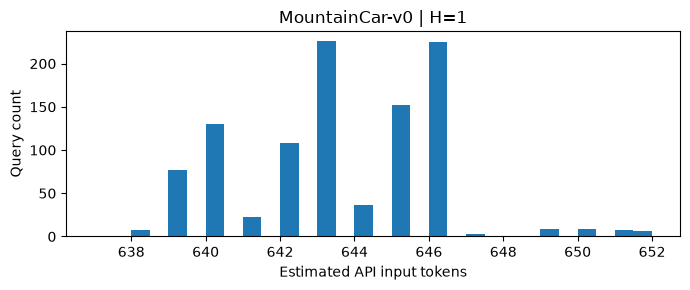

In [14]:
if not query_tokens.empty:
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.hist(query_tokens["input_tokens"], bins=30)
    ax.set_xlabel("Estimated API input tokens")
    ax.set_ylabel("Query count")
    ax.set_title(f"{DATASET} | H={query_tokens['history_size'].iloc[0]}")
    fig.tight_layout()
    plt.show()
else:
    print("Histogram: N/A")


## 10. history size比較

選択datasetに対してのみ計算します。各Hで有効query集合が変わるため、totalの差と同一queryの増加は別です。
各Hの全行はhistory_tables[H]に保持します。比較にはepisode_id / sequence_id / query_indexでjoinできます。
外部staticはH=0のみ表示します。


In [15]:
history_tables = {}
history_rows = []
if config is not None:
    hs = [0] if config["prompt_mode"] == "external_static" else sorted(set(HISTORY_SIZES))
    for h in hs:
        current_h = 0 if config["prompt_mode"] == "external_static" else HISTORY_SIZE
        if h == current_h:
            table, scope = query_tokens, count_scope
        else:
            table, scope = dataset_token_table(
                adapter, config, h, MODEL, METRIC, QUESTION_NAME,
                external_sequence=sequence.sequence_id if sequence else None,
                external_full_dataset=EXTERNAL_FULL_DATASET,
                max_external_queries=MAX_EXTERNAL_QUERIES,
            )
        history_tables[h] = table
        if table.empty:
            print(f"H={h}: no queries — {scope}")
            continue
        history_rows.append({"history_size": h, **table_statistics(table), "scope": scope})
history_comparison = pd.DataFrame(history_rows)
display(history_comparison if not history_comparison.empty else "History comparison: N/A")


,history_size,number_of_queries,mean,std,min,max,median,p95,total_input_tokens,scope
0,0,1031,611.271581,1.885664,607,619,611,613,630221,all dataset episodes / full valid queries
1,1,1021,643.369246,2.651076,637,652,643,646,656880,all dataset episodes / full valid queries
2,2,1011,675.474777,3.399847,668,686,675,679,682905,all dataset episodes / full valid queries
3,3,1001,707.590410,4.123962,699,718,707,713,708298,all dataset episodes / full valid queries
4,5,981,771.849134,5.505411,760,784,771,779,757184,all dataset episodes / full valid queries


## 11. 保存済み全dataset token summary

outputs/token_counts/token_inventory.csvがあれば読み込むだけです。model/tokenizerの保存時情報も表示します。
**この表は現在のconfigurationで再計算した結果ではありません。**
prompt_mode・H・config SHA・全件/sample scopeを維持し、混ぜて合計しません。
CSVがなければbatchを起動せずメッセージだけ表示します。


In [16]:
batch_summary = read_batch_summary()
if batch_summary is None:
    print("Token batch has not been executed yet.")
else:
    metadata_path = ROOT / "outputs/token_counts/summary.json"
    if metadata_path.is_file():
        metadata = json.loads(metadata_path.read_text())
        print("Saved batch model:", metadata.get("model"), "tokenizer:", metadata.get("tokenizer"))
    batch_columns = [
        "dataset", "n_units", "prompt_mode", "history_size", "count_scope",
        "mean_input_tokens", "std_input_tokens", "min_input_tokens", "max_input_tokens",
        "p95_input_tokens", "total_input_tokens", "preprocessing_config_sha256",
    ]
    with pd.option_context("display.max_rows", None):
        display(batch_summary[[c for c in batch_columns if c in batch_summary]])
    print("No batch was started. Existing results were read only.")


Saved batch model: gpt-4o tokenizer: o200k_base


,dataset,n_units,prompt_mode,history_size,count_scope,mean_input_tokens,std_input_tokens,min_input_tokens,max_input_tokens,p95_input_tokens,total_input_tokens,preprocessing_config_sha256
0,Acrobot-v1,394,original_llmx,0,full_selected_scope,829.604061,2.687739,824,851,832,326864,93dfa8c41a457a02bc85c81dcf71a31bf96226ea544bc7...
1,Acrobot-v1,389,original_llmx,1,full_selected_scope,887.868895,3.258492,880,910,890,345381,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b...
2,Acrobot-v1,384,original_llmx,2,full_selected_scope,946.148438,3.760589,938,969,949,363321,e65b1fd900a1a9f5fc12e4409906252cebd7498879e226...
3,Acrobot-v1,379,original_llmx,3,full_selected_scope,1004.432718,4.279495,996,1028,1008,380680,c0c4a33cf5f4d0c0bc4f4b7d57e8227c90e984b61cce88...
4,Acrobot-v1,369,original_llmx,5,full_selected_scope,1120.978320,5.256517,1112,1146,1126,413641,8f9e90a0f3fdba34c0f15aa6a4ae696fa21b4db2805e19...
5,Acrobot-v1,344,original_llmx,10,full_selected_scope,1412.287791,7.274220,1400,1438,1429,485827,aa547e15a1fa5f9d58e077cd5bc5b80fa8ddc06e53de3a...
6,CartPole-v1,2495,original_llmx,0,full_selected_scope,785.440080,2.056203,781,799,787,1959673,93dfa8c41a457a02bc85c81dcf71a31bf96226ea544bc7...
7,CartPole-v1,2490,original_llmx,1,full_selected_scope,830.610040,2.619846,825,845,833,2068219,08dcac0bdc5397de4bf8cc6a1df8833e2094350602bf0b...
8,CartPole-v1,2485,original_llmx,2,full_selected_scope,875.781087,3.118770,868,891,879,2176316,e65b1fd900a1a9f5fc12e4409906252cebd7498879e226...
9,CartPole-v1,2480,original_llmx,3,full_selected_scope,920.946774,3.566928,912,936,925,2283948,c0c4a33cf5f4d0c0bc4f4b7d57e8227c90e984b61cce88...


No batch was started. Existing results were read only.


### 処理の所在

- 一覧: tools/list_datasets.py、保存済みoutputs/dataset_inventory/
- raw読込: dataset_adapters/、再照合: tools/inventory_llmx_data.py / inventory_candidates.py
- prompt: preprocessing/llmx_original.py / prompting.py（Notebook内では再実装しない）
- local token / 統計: tools/count_input_tokens.py
- 閲覧用の表への整形: tools/notebook_inspection.py

参考: [OpenAI GPT-4o](https://developers.openai.com/api/docs/models/gpt-4o)、[Text generation](https://developers.openai.com/api/docs/guides/text)。
ここではモデル推論もAPI呼び出しも行っていません。
